In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
Merge CVAT-annotated Pickleball clips into a unified TrackNetV5 dataset.

HOW IT WORKS:
  - Reads each clip's annotations.xml (CVAT 1.1 format)
  - Renames frames with a global prefix: g1_c1_000000.jpg, g1_c2_000000.jpg ...
  - Copies renamed frames into one flat folder: dataset/images/
  - Produces a single CSV: dataset/labels.csv with columns:
      file_name, x, y, visibility
    where visibility = 1 if ball is labeled, 0 if ball is not visible/missing

USAGE (in Google Colab):
  1. Mount Google Drive
  2. Set BASE_DIR and OUT_DIR below
  3. Run: !python merge_cvat_to_tracknetv5.py

TRACKNETV5 CSV FORMAT:
  file_name       - frame filename in the images/ folder
  x               - ball center x (float), -1 if not visible
  y               - ball center y (float), -1 if not visible
  visibility      - 1 = visible, 0 = not visible / occluded / missing
"""

import os
import shutil
import xml.etree.ElementTree as ET
import csv
from pathlib import Path

# ─────────────────────────────────────────────
# CONFIG — Edit these paths before running
# ─────────────────────────────────────────────

BASE_DIR = '/content/drive/MyDrive/In_Out_Pickleball'

# All clip folders relative to BASE_DIR
CLIP_FOLDERS = [
    'game_1/clip_1/frames',
    'game_1/clip_2/frames',
    'game_1/clip_4/frames',
    'game_1/clip_5/frames',
    'game_2/clip_1/frames',
    'game_2/clip_2/frames',
    'game_2/clip_3/frames',
    'game_2/clip_4/frames',
    'game_2/clip_5/frames',
    'game_3/clip_1/frames',
    'game_3/clip_2/frames',
    'game_3/clip_3/frames',
    'game_3/clip_4/frames',
    'game_3/clip_5/frames',
    'game_4/Clip_1/frames',
    'game_4/Clip_2/frames',
    'game_4/Clip_3/frames',
    'game_4/Clip_4/frames',
    'game_4/Clip_5/frames',
    'game_5/clip_1/frames',
    # Add more clips here if needed
]

# Output directory (will be created if not exists)
OUT_DIR = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset'

# Set to True to copy images, False to only generate the CSV (faster for testing)
COPY_IMAGES = True

# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

In [3]:
def parse_annotations(xml_path):
    """
    Parse a CVAT 1.1 annotations.xml.
    Returns a dict: { frame_id (int) -> {'name': str, 'x': float|None, 'y': float|None} }
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    frames = {}
    for image_el in root.findall('image'):
        frame_id = int(image_el.get('id'))
        name = image_el.get('name')   # e.g. "000042.jpg"
        x, y = None, None
        for points_el in image_el.findall('points'):
            label = points_el.get('label', '')
            if label == 'Ball':
                raw = points_el.get('points', '')
                if raw:
                    parts = raw.split(',')
                    if len(parts) == 2:
                        x = float(parts[0].strip())
                        y = float(parts[1].strip())
                break  # Only one ball per frame
        frames[frame_id] = {'name': name, 'x': x, 'y': y}
    return frames


def clip_prefix(folder_rel_path):
    """
    Convert 'game_1/clip_2/frames' -> 'g1_c2'
    Handles both lower and Title case (clip/Clip).
    """
    parts = Path(folder_rel_path).parts  # ('game_1', 'clip_2', 'frames')
    game_part = parts[0]   # 'game_1'
    clip_part = parts[1]   # 'clip_2' or 'Clip_3'

    game_num = game_part.split('_')[-1]
    clip_num = clip_part.split('_')[-1]
    return f'g{game_num}_c{clip_num}'


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def main():
    images_out = Path(OUT_DIR) / 'images'
    images_out.mkdir(parents=True, exist_ok=True)

    csv_path = Path(OUT_DIR) / 'labels.csv'

    total_frames = 0
    total_visible = 0
    missing_xml = []
    missing_images = []

    with open(csv_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['file_name', 'x', 'y', 'visibility'])

        for folder_rel in CLIP_FOLDERS:
            folder_abs = Path(BASE_DIR) / folder_rel
            xml_path = folder_abs / 'annotations.xml'

            if not xml_path.exists():
                print(f'[SKIP] No annotations.xml in: {folder_abs}')
                missing_xml.append(str(folder_abs))
                continue

            prefix = clip_prefix(folder_rel)
            print(f'Processing {folder_rel}  →  prefix: {prefix}')

            frames = parse_annotations(str(xml_path))

            clip_frames = 0
            clip_visible = 0

            for frame_id in sorted(frames.keys()):
                info = frames[frame_id]
                orig_name = info['name']         # e.g. "000042.jpg"
                new_name = f'{prefix}_{orig_name}'  # e.g. "g1_c2_000042.jpg"

                src_path = folder_abs / orig_name
                dst_path = images_out / new_name

                # Copy image
                if COPY_IMAGES:
                    if src_path.exists():
                        if not dst_path.exists():  # skip if already copied
                            shutil.copy2(str(src_path), str(dst_path))
                    else:
                        missing_images.append(str(src_path))
                        print(f'  [WARN] Image not found: {src_path}')

                # Write CSV row
                if info['x'] is not None and info['y'] is not None:
                    writer.writerow([new_name, round(info['x'], 2), round(info['y'], 2), 1])
                    clip_visible += 1
                else:
                    writer.writerow([new_name, -1, -1, 0])

                clip_frames += 1

            total_frames += clip_frames
            total_visible += clip_visible
            print(f'  → {clip_frames} frames | {clip_visible} visible ball | '
                  f'{clip_frames - clip_visible} not visible')

    # Summary
    print('\n' + '=' * 60)
    print('DONE!')
    print(f'  Total frames processed : {total_frames}')
    print(f'  Ball visible           : {total_visible}')
    print(f'  Ball not visible       : {total_frames - total_visible}')
    print(f'  Visibility ratio       : {total_visible/total_frames*100:.1f}%' if total_frames else '')
    print(f'  CSV saved to           : {csv_path}')
    print(f'  Images saved to        : {images_out}')
    if missing_xml:
        print(f'\n  [!] Missing annotations.xml in {len(missing_xml)} folder(s):')
        for p in missing_xml:
            print(f'      {p}')
    if missing_images:
        print(f'\n  [!] {len(missing_images)} image file(s) not found (listed above)')
    print('=' * 60)


if __name__ == '__main__':
    main()

Processing game_1/clip_1/frames  →  prefix: g1_c1
  → 608 frames | 506 visible ball | 102 not visible
Processing game_1/clip_2/frames  →  prefix: g1_c2
  → 308 frames | 245 visible ball | 63 not visible
Processing game_1/clip_4/frames  →  prefix: g1_c4
  → 712 frames | 659 visible ball | 53 not visible
Processing game_1/clip_5/frames  →  prefix: g1_c5
  → 406 frames | 328 visible ball | 78 not visible
Processing game_2/clip_1/frames  →  prefix: g2_c1
  → 840 frames | 822 visible ball | 18 not visible
Processing game_2/clip_2/frames  →  prefix: g2_c2
  → 678 frames | 561 visible ball | 117 not visible
Processing game_2/clip_3/frames  →  prefix: g2_c3
  → 534 frames | 496 visible ball | 38 not visible
Processing game_2/clip_4/frames  →  prefix: g2_c4
  → 616 frames | 608 visible ball | 8 not visible
Processing game_2/clip_5/frames  →  prefix: g2_c5
  → 827 frames | 788 visible ball | 39 not visible
[SKIP] No annotations.xml in: /content/drive/MyDrive/In_Out_Pickleball/game_3/clip_1/frame

In [4]:
import subprocess
subprocess.run(['pip', 'install', 'einops', 'timm', '--quiet'])

CompletedProcess(args=['pip', 'install', 'einops', 'timm', '--quiet'], returncode=0)

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Global Config                                 ║
# ╚══════════════════════════════════════════════════════════╝

import os

# ── Paths ────────────────────────────────────────────────
DATASET_DIR   = '/content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset'
IMAGES_DIR    = os.path.join(DATASET_DIR, 'images')
LABELS_CSV    = os.path.join(DATASET_DIR, 'labels.csv')
CKPT_DIR      = os.path.join(DATASET_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Input / Output resolution (paper: 512×288) ──────────
IMG_W, IMG_H  = 512, 288

# ── Heatmap Gaussian radius (paper: r=40 for 1920×1080) ─
HEATMAP_RADIUS = 40

# ── Training ─────────────────────────────────────────────
BATCH_SIZE    = 2        # paper uses 2 on RTX 4090
NUM_EPOCHS    = 30
LR            = 1e-4
LR_DECAY_EPOCHS = [20, 25]
LR_GAMMA      = 0.1
VAL_SPLIT     = 0.3
SEED          = 42

# ── Early Stopping ───────────────────────────────────────
EARLY_STOP_PATIENCE = 7   # epochs without F1 improvement

# ── Evaluation tolerance (paper: 4 px at original res) ──
# Scale to 512×288: 4 * (512/1920) ≈ 1.07  → use 4 px at output
EVAL_TOLERANCE = 4

# ── Device ───────────────────────────────────────────────
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Config loaded | Device: {DEVICE}")
print(f"   Images : {IMAGES_DIR}")
print(f"   Labels : {LABELS_CSV}")

✅ Config loaded | Device: cuda
   Images : /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/images
   Labels : /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/labels.csv


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 3 — STEP 1: Preprocess — Verify Annotations      ║
# ╚══════════════════════════════════════════════════════════╝
"""
Reads labels.csv (produced by merge_cvat_to_tracknetv5.py).
Checks:
  • Every filename in CSV actually exists in images/
  • Ball coordinates are within image bounds (or visibility=0)
  • Reports summary statistics
Outputs: cleaned labels.csv (bad rows flagged, not deleted)
"""

import pandas as pd
import numpy as np
from PIL import Image

print("=" * 60)
print("STEP 1 — Annotation Verification")
print("=" * 60)

df = pd.read_csv(LABELS_CSV)
print(f"Total rows in CSV : {len(df)}")

issues = []
missing_files = 0
out_of_bounds  = 0
ok_rows        = 0

for idx, row in df.iterrows():
    img_path = os.path.join(IMAGES_DIR, row['file_name'])

    # Check file existence
    if not os.path.exists(img_path):
        issues.append({'idx': idx, 'file': row['file_name'], 'issue': 'FILE_MISSING'})
        missing_files += 1
        continue

    # Check coordinate bounds for visible balls
    if row['visibility'] == 1:
        x, y = row['x'], row['y']
        if not (0 <= x <= IMG_W * (1920 / 512)) or not (0 <= y <= IMG_H * (1080 / 288)):
            # coords are in original space (1920×1080), allow up to those bounds
            if not (0 <= x <= 1920) or not (0 <= y <= 1080):
                issues.append({'idx': idx, 'file': row['file_name'],
                                'issue': f'OUT_OF_BOUNDS x={x:.1f} y={y:.1f}'})
                out_of_bounds += 1
                continue
    ok_rows += 1

print(f"\n  ✅ OK rows        : {ok_rows}")
print(f"  ❌ Missing files   : {missing_files}")
print(f"  ⚠️  Out-of-bounds  : {out_of_bounds}")

if issues:
    issues_df = pd.DataFrame(issues)
    issues_path = os.path.join(DATASET_DIR, 'annotation_issues.csv')
    issues_df.to_csv(issues_path, index=False)
    print(f"\n  Issue log saved → {issues_path}")
    # Remove bad rows
    bad_idx = [i['idx'] for i in issues]
    df_clean = df.drop(index=bad_idx).reset_index(drop=True)
else:
    df_clean = df.copy()

# Visibility stats
n_visible = (df_clean['visibility'] == 1).sum()
n_hidden  = (df_clean['visibility'] == 0).sum()
print(f"\n  Ball visible      : {n_visible} ({n_visible/len(df_clean)*100:.1f}%)")
print(f"  Ball not visible  : {n_hidden}  ({n_hidden/len(df_clean)*100:.1f}%)")

# Save cleaned CSV
clean_csv = os.path.join(DATASET_DIR, 'labels_clean.csv')
df_clean.to_csv(clean_csv, index=False)
print(f"\n✅ Clean CSV saved → {clean_csv}")

STEP 1 — Annotation Verification
Total rows in CSV : 7552

  ✅ OK rows        : 7552
  ❌ Missing files   : 0
  ⚠️  Out-of-bounds  : 0

  Ball visible      : 6889 (91.2%)
  Ball not visible  : 663  (8.8%)

✅ Clean CSV saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/labels_clean.csv


In [7]:

#  ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — STEP 2: Build Consecutive-Frame Sequences    ║
# ╚══════════════════════════════════════════════════════════╝
"""
TrackNetV5 input: 3 consecutive frames (t-1, t, t+1).
Each sample = (frame_t-1, frame_t, frame_t+1) → predict heatmap at t.

Rules:
  • Frames must belong to the SAME clip (same g{i}_c{j}_ prefix).
  • No wrapping across clip boundaries.
  • Produces a list of (f_prev, f_curr, f_next, x, y, vis) tuples.
"""

import re
from collections import defaultdict

print("=" * 60)
print("STEP 2 — Building Consecutive-Frame Sequences")
print("=" * 60)

df_clean = pd.read_csv(clean_csv)

# ── Group rows by clip prefix ─────────────────────────────
def get_clip_prefix(fname):
    # e.g. 'g1_c2_000042.jpg' → 'g1_c2'
    m = re.match(r'^(g\d+_c\d+)_', fname)
    return m.group(1) if m else 'unknown'

def get_frame_num(fname):
    # e.g. 'g1_c2_000042.jpg' → 42
    m = re.search(r'_(\d+)\.jpg$', fname)
    return int(m.group(1)) if m else -1

df_clean['clip']      = df_clean['file_name'].apply(get_clip_prefix)
df_clean['frame_num'] = df_clean['file_name'].apply(get_frame_num)
df_clean = df_clean.sort_values(['clip', 'frame_num']).reset_index(drop=True)

# ── Build lookup: (clip, frame_num) → row ────────────────
lookup = {}
for _, row in df_clean.iterrows():
    lookup[(row['clip'], row['frame_num'])] = row

# ── Build sequences ───────────────────────────────────────
sequences = []  # each entry: dict with prev/curr/next info
skipped   = 0

for _, row in df_clean.iterrows():
    clip = row['clip']
    fn   = row['frame_num']

    prev_key = (clip, fn - 1)
    next_key = (clip, fn + 1)

    if prev_key not in lookup or next_key not in lookup:
        skipped += 1
        continue  # boundary frame — cannot form a triplet

    prev_row = lookup[prev_key]
    next_row = lookup[next_key]

    sequences.append({
        'f_prev' : prev_row['file_name'],
        'f_curr' : row['file_name'],
        'f_next' : next_row['file_name'],
        'x'      : row['x'],
        'y'      : row['y'],
        'vis'    : row['visibility'],
    })

seq_df = pd.DataFrame(sequences)
seq_path = os.path.join(DATASET_DIR, 'sequences.csv')
seq_df.to_csv(seq_path, index=False)

print(f"  Total frames           : {len(df_clean)}")
print(f"  Skipped (boundary)     : {skipped}")
print(f"  Valid triplet sequences: {len(sequences)}")
print(f"  Visible ball sequences : {(seq_df['vis']==1).sum()}")
print(f"\n✅ Sequences saved → {seq_path}")


STEP 2 — Building Consecutive-Frame Sequences
  Total frames           : 7552
  Skipped (boundary)     : 30
  Valid triplet sequences: 7522
  Visible ball sequences : 6867

✅ Sequences saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/sequences.csv


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — STEP 3: Dataset & DataLoader                 ║
# ╚══════════════════════════════════════════════════════════╝

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import cv2
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Heatmap Generator ────────────────────────────────────
def make_heatmap(cx, cy, vis, H=IMG_H, W=IMG_W,
                 orig_w=1920, orig_h=1080, radius=HEATMAP_RADIUS):
    """
    Binary Gaussian-guided heatmap (paper eq. 5).
    cx, cy are in original resolution → scale to output resolution.
    """
    hm = np.zeros((H, W), dtype=np.float32)
    if vis == 0 or cx < 0:
        return hm
    # Scale coordinates
    sx = cx * W / orig_w
    sy = cy * H / orig_h
    # Scale radius
    sr = radius * W / orig_w
    # Draw binary circle
    ix, iy = int(round(sx)), int(round(sy))
    r = max(1, int(round(sr)))
    for dx in range(-r, r + 1):
        for dy in range(-r, r + 1):
            if dx * dx + dy * dy <= r * r:
                nx, ny = ix + dx, iy + dy
                if 0 <= nx < W and 0 <= ny < H:
                    hm[ny, nx] = 1.0
    return hm

# ── Dataset ───────────────────────────────────────────────
class PickleballDataset(Dataset):
    def __init__(self, seq_df, images_dir, augment=False):
        self.seq      = seq_df.reset_index(drop=True)
        self.img_dir  = images_dir
        self.augment  = augment

    def __len__(self):
        return len(self.seq)

    def _load(self, fname):
        path = os.path.join(self.img_dir, fname)
        img  = cv2.imread(path)
        if img is None:
            raise FileNotFoundError(f"Cannot read: {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_W, IMG_H))
        return img  # H×W×3, uint8

    def __getitem__(self, idx):
        row = self.seq.iloc[idx]

        f_prev = self._load(row['f_prev'])
        f_curr = self._load(row['f_curr'])
        f_next = self._load(row['f_next'])

        # ── Random augmentation ───────────────────────────
        if self.augment:
            # Horizontal flip (all 3 frames + coords)
            if random.random() < 0.5:
                f_prev = cv2.flip(f_prev, 1)
                f_curr = cv2.flip(f_curr, 1)
                f_next = cv2.flip(f_next, 1)
                if row['vis'] == 1:
                    row = row.copy()
                    row['x'] = 1920 - row['x']

            # Brightness / contrast jitter (applied consistently)
            alpha = random.uniform(0.8, 1.2)   # contrast
            beta  = random.randint(-20, 20)     # brightness
            f_prev = np.clip(f_prev.astype(np.int32) * alpha + beta, 0, 255).astype(np.uint8)
            f_curr = np.clip(f_curr.astype(np.int32) * alpha + beta, 0, 255).astype(np.uint8)
            f_next = np.clip(f_next.astype(np.int32) * alpha + beta, 0, 255).astype(np.uint8)

        # ── To float tensors [0,1], shape C×H×W ──────────
        def to_tensor(img):
            return torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        t_prev = to_tensor(f_prev)  # 3×H×W
        t_curr = to_tensor(f_curr)
        t_next = to_tensor(f_next)

        # ── Heatmap ground truth ──────────────────────────
        hm = make_heatmap(row['x'], row['y'], row['vis'])
        hm_tensor = torch.from_numpy(hm).unsqueeze(0)  # 1×H×W

        # ── Stack frames: (t-1, t, t+1) → 9 channels ─────
        frames = torch.cat([t_prev, t_curr, t_next], dim=0)  # 9×H×W

        return frames, hm_tensor, torch.tensor(row['vis'], dtype=torch.float32)


# ── Train/Val split (by clip to avoid data leakage) ──────
seq_df = pd.read_csv(seq_path)
clips  = seq_df['f_curr'].apply(get_clip_prefix).unique()
random.shuffle(clips := list(clips))

n_val   = max(1, int(len(clips) * VAL_SPLIT))
val_clips = set(clips[:n_val])
trn_clips = set(clips[n_val:])

trn_df = seq_df[seq_df['f_curr'].apply(get_clip_prefix).isin(trn_clips)].reset_index(drop=True)
val_df = seq_df[seq_df['f_curr'].apply(get_clip_prefix).isin(val_clips)].reset_index(drop=True)

print(f"Train sequences: {len(trn_df)} | clips: {len(trn_clips)}")
print(f"Val   sequences: {len(val_df)} | clips: {len(val_clips)}")

train_ds = PickleballDataset(trn_df, IMAGES_DIR, augment=True)
val_ds   = PickleballDataset(val_df, IMAGES_DIR, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print("✅ DataLoaders ready.")

Train sequences: 5055 | clips: 11
Val   sequences: 2467 | clips: 4
✅ DataLoaders ready.


In [9]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6B — STEP 4: TrackNetV5 Model Architecture       ║
# ╚══════════════════════════════════════════════════════════╝
"""
Implements:
  1. MDD  — Motion Direction Decoupling
  2. V2 Backbone — U-Net Encoder-Decoder
  3. R-STR — Residual-Driven Spatio-Temporal Refinement
             with TSATTHead (factorized spatial+temporal attention)

Fixes applied vs previous version:
  - norm_first=False  → eliminates nested_tensor warning
  - batch_first=True  kept, dropout tuned for small GPU memory
  - Model tested on CUDA 12.8 / sm_120 (Blackwell RTX PRO 6000)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F

# Verify correct PyTorch + CUDA version loaded
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    cap = torch.cuda.get_device_capability(0)
    print(f"CUDA capability : sm_{cap[0]}{cap[1]}")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device    : {DEVICE}\n")

# ── MDD: Motion Direction Decoupling ─────────────────────
class MDDLayer(nn.Module):
    """
    Decomposes frame difference into positive (brightening)
    and negative (darkening) polarity channels.
    Applies learnable sigmoid attention (paper eq. 2-3).
    """
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta  = nn.Parameter(torch.zeros(1))

    def _attention(self, polarity):
        k = 5.0 / (0.45 * torch.tanh(self.alpha).abs() + 1e-6)
        m = 0.6 * torch.tanh(self.beta)
        return torch.sigmoid(k * (polarity.abs() - m))

    def forward(self, frames):
        """
        frames: B×9×H×W  (I_{t-1} | I_t | I_{t+1}, each 3ch)
        Returns:
          Xin        : B×13×H×W
          motion_attn: B×4×H×W  (for R-STR skip connection)
        """
        I_prev = frames[:, 0:3]
        I_curr = frames[:, 3:6]
        I_next = frames[:, 6:9]

        D1 = I_curr - I_prev
        D2 = I_next - I_curr

        D1_g = D1.mean(dim=1, keepdim=True)
        D2_g = D2.mean(dim=1, keepdim=True)

        P1_pos = F.relu( D1_g)
        P1_neg = F.relu(-D1_g)
        P2_pos = F.relu( D2_g)
        P2_neg = F.relu(-D2_g)

        A1_pos = self._attention(P1_pos)
        A1_neg = self._attention(P1_neg)
        A2_pos = self._attention(P2_pos)
        A2_neg = self._attention(P2_neg)

        A1 = torch.cat([A1_pos, A1_neg], dim=1)  # B×2×H×W
        A2 = torch.cat([A2_pos, A2_neg], dim=1)

        Xin         = torch.cat([I_prev, A1, I_curr, A2, I_next], dim=1)  # B×13×H×W
        motion_attn = torch.cat([A1, A2], dim=1)                           # B×4×H×W

        return Xin, motion_attn


# ── V2 Encoder-Decoder Backbone ──────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            ConvBnRelu(in_ch,  out_ch),
            ConvBnRelu(out_ch, out_ch),
        )
    def forward(self, x): return self.block(x)

class V2Backbone(nn.Module):
    """
    U-Net style encoder-decoder.
    Input : B×13×H×W
    Output: B×64×H×W
    """
    def __init__(self, in_ch=13):
        super().__init__()
        self.enc1     = DoubleConv(in_ch, 64)
        self.pool1    = nn.MaxPool2d(2)
        self.enc2     = DoubleConv(64, 128)
        self.pool2    = nn.MaxPool2d(2)
        self.enc3     = DoubleConv(128, 256)
        self.pool3    = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up3      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3     = DoubleConv(512 + 256, 256)
        self.up2      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2     = DoubleConv(256 + 128, 128)
        self.up1      = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1     = DoubleConv(128 + 64, 64)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return d1  # B×64×H×W


# ── TSATTHead ─────────────────────────────────────────────
class TSATTHead(nn.Module):
    """
    Lightweight Transformer head estimating residual Δ.
    FIX: norm_first=False to eliminate nested_tensor warning
         and ensure compatibility across all GPU architectures.
    """
    def __init__(self, in_ch=5, patch=8, dim=128, heads=4, layers=2):
        super().__init__()
        self.patch = patch
        self.dim   = dim

        self.patch_embed = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)

        max_tokens = (IMG_H // patch) * (IMG_W // patch)
        self.pos_embed = nn.Parameter(torch.randn(1, max_tokens, dim) * 0.02)

        # ── KEY FIX: norm_first=False ──────────────────────
        # norm_first=True triggers a PyTorch warning about
        # enable_nested_tensor being disabled, which also
        # causes slow paths on non-standard GPU architectures.
        # norm_first=False (Pre-LN off) is the stable default.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=heads,
            dim_feedforward=dim * 4,
            dropout=0.1,
            batch_first=True,
            norm_first=False,          # ← FIXED (was True)
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
            enable_nested_tensor=False  # ← explicitly disable to avoid warning
        )

        self.head = nn.Linear(dim, patch * patch)

    def forward(self, x):
        B, C, H, W = x.shape
        tokens = self.patch_embed(x)
        ph, pw = tokens.shape[2], tokens.shape[3]
        tokens = tokens.flatten(2).transpose(1, 2)   # B×N×dim
        N      = tokens.shape[1]
        tokens = tokens + self.pos_embed[:, :N, :]
        tokens = self.transformer(tokens)             # B×N×dim
        pixels = self.head(tokens)                    # B×N×(p*p)
        pixels = pixels.transpose(1, 2)               # B×(p*p)×N
        pixels = pixels.reshape(B, self.patch * self.patch, ph, pw)
        residual = F.pixel_shuffle(pixels, self.patch) # B×1×H×W
        return residual


# ── R-STR ─────────────────────────────────────────────────
class RSTR(nn.Module):
    def __init__(self, feat_ch=64, dropout_p=0.1):
        super().__init__()
        self.draft_conv = nn.Conv2d(feat_ch, 1, kernel_size=1)
        self.tsatt      = TSATTHead(in_ch=5)   # draft(1) + motion_attn(4)
        self.dropout    = nn.Dropout2d(p=dropout_p)

    def forward(self, dec_feat, motion_attn):
        draft     = self.draft_conv(dec_feat)              # B×1×H×W
        draft_mdd = torch.cat([draft, motion_attn], dim=1) # B×5×H×W

        if self.training:
            draft_masked = self.dropout(draft)
            draft_mdd_in = torch.cat([draft_masked, motion_attn], dim=1)
        else:
            draft_mdd_in = draft_mdd

        delta   = self.tsatt(draft_mdd_in)                 # B×1×H×W
        H_final = torch.sigmoid(draft + delta)             # B×1×H×W
        return H_final


# ── Full TrackNetV5 ───────────────────────────────────────
class TrackNetV5(nn.Module):
    def __init__(self):
        super().__init__()
        self.mdd      = MDDLayer()
        self.backbone = V2Backbone(in_ch=13)
        self.rstr     = RSTR(feat_ch=64)

    def forward(self, frames):
        """
        frames: B×9×H×W
        Returns: B×1×H×W heatmap
        """
        Xin, motion_attn = self.mdd(frames)
        dec_feat          = self.backbone(Xin)
        heatmap           = self.rstr(dec_feat, motion_attn)
        return heatmap


# ── Sanity check ─────────────────────────────────────────
model = TrackNetV5().to(DEVICE)
dummy = torch.randn(2, 9, IMG_H, IMG_W).to(DEVICE)

with torch.no_grad():
    out = model(dummy)

print(f"✅ Model output shape : {out.shape}")   # expect (2, 1, 288, 512)
print(f"   Output range       : [{out.min():.3f}, {out.max():.3f}]")

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params   : {n_params/1e6:.2f} M")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA A100-SXM4-40GB
CUDA capability : sm_80
Using device    : cuda

✅ Model output shape : torch.Size([2, 1, 288, 512])
   Output range       : [0.074, 0.956]
   Trainable params   : 8.53 M


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 6 — STEP 4: TrackNetV5 Model Architecture        ║
# ╚══════════════════════════════════════════════════════════╝
"""
Implements:
  1. MDD  — Motion Direction Decoupling (polarity decomposition
             + learnable sigmoid attention)
  2. V2 Backbone — U-Net Encoder-Decoder
  3. R-STR — Residual-Driven Spatio-Temporal Refinement
             with TSATTHead (factorized spatial+temporal attention)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange

# ── MDD: Motion Direction Decoupling ─────────────────────
class MDDLayer(nn.Module):
    """
    Decomposes frame difference into positive (brightening)
    and negative (darkening) polarity channels.
    Applies learnable sigmoid attention (paper eq. 2-3).
    """
    def __init__(self):
        super().__init__()
        # Learnable params per polarity (shared across intervals)
        self.alpha = nn.Parameter(torch.zeros(1))
        self.beta  = nn.Parameter(torch.zeros(1))

    def _attention(self, polarity):
        k = 5.0 / (0.45 * torch.tanh(self.alpha).abs() + 1e-6)
        m = 0.6 * torch.tanh(self.beta)
        return torch.sigmoid(k * (polarity.abs() - m))

    def forward(self, frames):
        """
        frames: B×9×H×W  (I_{t-1} | I_t | I_{t+1}, each 3ch)
        Returns:
          Xin : B×13×H×W  (I_{t-1}|A_{t-1,t}|I_t|A_{t,t+1}|I_{t+1})
          motion_attn: B×4×H×W  (for R-STR skip connection)
        """
        I_prev = frames[:, 0:3]   # B×3×H×W
        I_curr = frames[:, 3:6]
        I_next = frames[:, 6:9]

        # Raw difference maps (eq. before eq.1)
        D1 = I_curr - I_prev   # D_{t-1→t}
        D2 = I_next - I_curr   # D_{t→t+1}

        # Polarity decomposition (eq. 1) — grayscale mean
        D1_g = D1.mean(dim=1, keepdim=True)
        D2_g = D2.mean(dim=1, keepdim=True)

        P1_pos = F.relu( D1_g)   # brightening
        P1_neg = F.relu(-D1_g)   # darkening

        P2_pos = F.relu( D2_g)
        P2_neg = F.relu(-D2_g)

        # Learnable attention (eq. 2-3)
        A1_pos = self._attention(P1_pos)
        A1_neg = self._attention(P1_neg)
        A2_pos = self._attention(P2_pos)
        A2_neg = self._attention(P2_neg)

        # A_{t-1,t}: 2 channels, A_{t,t+1}: 2 channels
        A1 = torch.cat([A1_pos, A1_neg], dim=1)  # B×2×H×W
        A2 = torch.cat([A2_pos, A2_neg], dim=1)

        # Motion-augmented input (eq. 4): 3+2+3+2+3 = 13 channels
        Xin = torch.cat([I_prev, A1, I_curr, A2, I_next], dim=1)

        # Motion attention for R-STR skip connection (4 channels)
        motion_attn = torch.cat([A1, A2], dim=1)

        return Xin, motion_attn


# ── V2 Encoder-Decoder Backbone ──────────────────────────
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            ConvBnRelu(in_ch,  out_ch),
            ConvBnRelu(out_ch, out_ch),
        )
    def forward(self, x): return self.block(x)

class V2Backbone(nn.Module):
    """
    U-Net style encoder-decoder as in TrackNetV2.
    Input : B×13×H×W (MDD output)
    Output: B×64×H×W (decoder features before final head)
    """
    def __init__(self, in_ch=13):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(in_ch, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = DoubleConv(512 + 256, 256)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = DoubleConv(256 + 128, 128)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = DoubleConv(128 + 64, 64)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        b  = self.bottleneck(self.pool3(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return d1  # B×64×H×W


# ── TSATTHead: factorized spatio-temporal self-attention ─
class TSATTHead(nn.Module):
    """
    Lightweight Transformer head that estimates residual Δ.
    Input : draft heatmaps fused with motion attention
            shape B×(3+4)×H×W
    Output: residual Δ  shape B×1×H×W
    Paper: patch embed → factorized space+time attention
           → PixelShuffle upsample → residual map
    """
    def __init__(self, in_ch=7, patch=8, dim=128, heads=4, layers=2):
        super().__init__()
        self.patch = patch
        self.dim   = dim

        # Patch embedding (non-overlapping)
        self.patch_embed = nn.Conv2d(in_ch, dim, kernel_size=patch, stride=patch)

        # Separate temporal & spatial encodings (factorized, paper sec 3.3.2)
        # We treat the 3 draft frames as "temporal tokens" and spatial patches as spatial
        # For simplicity: flat sequence with learned positional encoding
        max_tokens = (IMG_H // patch) * (IMG_W // patch)
        self.pos_embed = nn.Parameter(torch.randn(1, max_tokens, dim) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4,
            dropout=0.1, batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)

        # PixelShuffle decoder (patch^2 channels → 1 channel upsampled)
        self.head = nn.Sequential(
            nn.Linear(dim, patch * patch),
        )

    def forward(self, x):
        B, C, H, W = x.shape
        # Patch embed: B×dim×(H/p)×(W/p)
        tokens = self.patch_embed(x)
        ph, pw = tokens.shape[2], tokens.shape[3]
        # Flatten to sequence: B×N×dim
        tokens = tokens.flatten(2).transpose(1, 2)
        N = tokens.shape[1]
        tokens = tokens + self.pos_embed[:, :N, :]
        # Transformer
        tokens = self.transformer(tokens)          # B×N×dim
        # Decode to pixel space
        pixels = self.head(tokens)                 # B×N×(p*p)
        # Reshape to B×1×H×W via pixel shuffle
        pixels = pixels.transpose(1, 2)            # B×(p*p)×N
        pixels = pixels.reshape(B, self.patch * self.patch, ph, pw)
        # PixelShuffle: B×1×H×W
        residual = F.pixel_shuffle(pixels, self.patch)
        return residual   # B×1×H×W


# ── R-STR: Residual-Driven Spatio-Temporal Refinement ───
class RSTR(nn.Module):
    """
    Takes decoder features → 1×1 conv → 3 draft heatmaps
    Fuses drafts with motion attention maps (MDD skip connection)
    Applies stochastic context masking (dropout, train only)
    Estimates residual Δ via TSATTHead
    Final: sigmoid(draft + Δ)
    """
    def __init__(self, feat_ch=64, dropout_p=0.1):
        super().__init__()
        # Compress decoder features to 3 draft channels (one per frame)
        self.draft_conv = nn.Conv2d(feat_ch, 1, kernel_size=1)
        self.tsatt      = TSATTHead(in_ch=1 + 4)   # draft(1) + motion_attn(4)
        self.dropout    = nn.Dropout2d(p=dropout_p)

    def forward(self, dec_feat, motion_attn, training=True):
        """
        dec_feat    : B×64×H×W  (backbone decoder output)
        motion_attn : B×4×H×W   (MDD skip connection)
        """
        draft = self.draft_conv(dec_feat)           # B×1×H×W

        # Fuse draft with motion attention
        draft_mdd = torch.cat([draft, motion_attn], dim=1)  # B×5×H×W

        # Stochastic Context Masking (only training)
        if training:
            draft_mdd_masked = torch.cat([
                self.dropout(draft),
                motion_attn
            ], dim=1)
        else:
            draft_mdd_masked = draft_mdd

        # Estimate residual Δ
        delta = self.tsatt(draft_mdd_masked)         # B×1×H×W

        # Final prediction
        H_final = torch.sigmoid(draft + delta)       # B×1×H×W
        return H_final


# ── Full TrackNetV5 ───────────────────────────────────────
class TrackNetV5(nn.Module):
    def __init__(self):
        super().__init__()
        self.mdd      = MDDLayer()
        self.backbone = V2Backbone(in_ch=13)
        self.rstr     = RSTR(feat_ch=64)

    def forward(self, frames):
        """
        frames: B×9×H×W  (I_{t-1}, I_t, I_{t+1} concatenated)
        Returns: B×1×H×W heatmap for frame t
        """
        Xin, motion_attn = self.mdd(frames)
        dec_feat          = self.backbone(Xin)
        heatmap           = self.rstr(dec_feat, motion_attn,
                                      training=self.training)
        return heatmap


# ── Quick sanity check ────────────────────────────────────
model = TrackNetV5().to(DEVICE)
dummy = torch.randn(2, 9, IMG_H, IMG_W).to(DEVICE)
out   = model(dummy)
print(f"✅ Model output shape: {out.shape}")   # expect (2, 1, 288, 512)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Trainable params: {n_params/1e6:.2f} M")

✅ Model output shape: torch.Size([2, 1, 288, 512])
   Trainable params: 8.53 M


/tmp/ipykernel_10596/3819786472.py:167: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=layers)


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — STEP 5: Loss Function (WBCE)                 ║
# ╚══════════════════════════════════════════════════════════╝
"""
Weighted Binary Cross-Entropy (WBCE) from TrackNetV2 (paper eq. 6).
  L = -1/N Σ [ (1-p)² · y·log(p) + p² · (1-y)·log(1-p) ]
Addresses extreme foreground/background imbalance.
"""

class WBCELoss(nn.Module):
    def __init__(self, eps=1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        """
        pred   : B×1×H×W, values in [0,1] (after sigmoid)
        target : B×1×H×W, binary {0,1}
        """
        p = pred.clamp(self.eps, 1 - self.eps)
        y = target

        # Foreground loss: weight = (1-p)²
        fg = (1 - p).pow(2) * y * torch.log(p)
        # Background loss: weight = p²
        bg = p.pow(2) * (1 - y) * torch.log(1 - p)

        loss = -(fg + bg).mean()
        return loss

criterion = WBCELoss()
print("✅ WBCE Loss ready.")

# Verify loss output
with torch.no_grad():
    dummy_pred   = torch.sigmoid(torch.randn(2, 1, IMG_H, IMG_W))
    dummy_target = torch.randint(0, 2, (2, 1, IMG_H, IMG_W)).float()
    test_loss = criterion(dummy_pred, dummy_target)
    print(f"   Test loss value: {test_loss.item():.4f}")


✅ WBCE Loss ready.
   Test loss value: 0.3464


In [12]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 8 — STEP 6: Evaluation Metrics                   ║
# ╚══════════════════════════════════════════════════════════╝
"""
Standard TrackNet evaluation (paper sec 4.1):
  • TP : predicted center within EVAL_TOLERANCE px of GT
  • FP1: detection when no GT ball (false alarm)
  • FP2: detection but outside tolerance (wrong position)
  • FN : missed detection when GT ball present
  • TN : no detection and no GT ball (correct rejection)

Metrics: Accuracy, Precision, Recall, F1
"""

def extract_center(heatmap, threshold=0.5):
    """
    Given a B×1×H×W sigmoid heatmap,
    returns list of (x, y) or None for each item in batch.
    Uses the centroid of thresholded region.
    """
    heatmap = heatmap.squeeze(1).cpu().numpy()  # B×H×W
    centers = []
    for hm in heatmap:
        binary = (hm >= threshold).astype(np.uint8)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            centers.append(None)
        else:
            # Largest contour centroid
            c = max(contours, key=cv2.contourArea)
            M = cv2.moments(c)
            if M['m00'] == 0:
                centers.append(None)
            else:
                cx = M['m10'] / M['m00']
                cy = M['m01'] / M['m00']
                centers.append((cx, cy))
    return centers

def gt_center_from_heatmap(heatmap):
    """Extract GT center from binary heatmap."""
    heatmap = heatmap.squeeze(1).cpu().numpy()
    centers = []
    for hm in heatmap:
        ys, xs = np.where(hm > 0.5)
        if len(xs) == 0:
            centers.append(None)
        else:
            centers.append((xs.mean(), ys.mean()))
    return centers

def compute_metrics(tp, fp1, fp2, fn, tn):
    total = tp + fp1 + fp2 + fn + tn
    acc   = (tp + tn) / total if total > 0 else 0
    prec  = tp / (tp + fp1 + fp2) if (tp + fp1 + fp2) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    return acc, prec, rec, f1

@torch.no_grad()
def evaluate(model, loader, criterion, tol=EVAL_TOLERANCE):
    model.eval()
    total_loss = 0
    tp = fp1 = fp2 = fn = tn = 0

    for frames, hm_gt, vis in loader:
        frames = frames.to(DEVICE)
        hm_gt  = hm_gt.to(DEVICE)

        pred = model(frames)
        loss = criterion(pred, hm_gt)
        total_loss += loss.item()

        pred_centers = extract_center(pred.detach())
        gt_centers   = gt_center_from_heatmap(hm_gt.detach())

        for pc, gc, v in zip(pred_centers, gt_centers, vis):
            has_gt   = (v.item() == 1)
            has_pred = (pc is not None)

            if has_gt and has_pred:
                dist = np.sqrt((pc[0]-gc[0])**2 + (pc[1]-gc[1])**2)
                if dist <= tol:
                    tp  += 1
                else:
                    fp2 += 1
            elif has_gt and not has_pred:
                fn  += 1
            elif not has_gt and has_pred:
                fp1 += 1
            else:
                tn  += 1

    avg_loss        = total_loss / len(loader)
    acc, prec, rec, f1 = compute_metrics(tp, fp1, fp2, fn, tn)
    return avg_loss, acc, prec, rec, f1, tp, fp1, fp2, fn, tn

print("✅ Evaluation metrics ready.")


✅ Evaluation metrics ready.


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — STEP 7: Training Loop + Early Stopping       ║
# ╚══════════════════════════════════════════════════════════╝

from torch.optim import AdamW
from torch.optim.lr_scheduler import MultiStepLR

# ── Optimizer & Scheduler ────────────────────────────────
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = MultiStepLR(optimizer, milestones=LR_DECAY_EPOCHS, gamma=LR_GAMMA)

# ── History ───────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'val_acc': [], 'val_prec': [], 'val_rec': [], 'val_f1': []
}

best_f1       = 0.0
patience_cnt  = 0
best_ckpt     = os.path.join(CKPT_DIR, 'best_tracknetv5.pth')
last_ckpt     = os.path.join(CKPT_DIR, 'last_tracknetv5.pth')

print("=" * 60)
print("STEP 7 — Training TrackNetV5")
print("=" * 60)
print(f"Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR}")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE} epochs")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for step, (frames, hm_gt, vis) in enumerate(train_loader):
        frames = frames.to(DEVICE)
        hm_gt  = hm_gt.to(DEVICE)

        optimizer.zero_grad()
        pred = model(frames)
        loss = criterion(pred, hm_gt)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        train_loss += loss.item()

        if (step + 1) % 50 == 0:
            print(f"  Epoch {epoch:02d} | Step {step+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f}")

    train_loss /= len(train_loader)
    scheduler.step()

    # ── Validate ──────────────────────────────────────────
    val_loss, acc, prec, rec, f1, tp, fp1, fp2, fn, tn = \
        evaluate(model, val_loader, criterion)

    # ── Log ───────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(acc)
    history['val_prec'].append(prec)
    history['val_rec'].append(rec)
    history['val_f1'].append(f1)

    lr_now = scheduler.get_last_lr()[0]
    print(f"\nEpoch {epoch:02d}/{NUM_EPOCHS} | LR: {lr_now:.2e}")
    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"  Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    print(f"  TP:{tp}  FP1:{fp1}  FP2:{fp2}  FN:{fn}  TN:{tn}")

    # ── Save last checkpoint ──────────────────────────────
    torch.save({
        'epoch': epoch, 'model_state': model.state_dict(),
        'optim_state': optimizer.state_dict(),
        'best_f1': best_f1, 'history': history
    }, last_ckpt)

    # ── Early stopping & best checkpoint ─────────────────
    if f1 > best_f1:
        best_f1      = f1
        patience_cnt = 0
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'best_f1': best_f1
        }, best_ckpt)
        print(f"  🏆 New best F1: {best_f1:.4f} → checkpoint saved")
    else:
        patience_cnt += 1
        print(f"  ⏳ No improvement. Patience: {patience_cnt}/{EARLY_STOP_PATIENCE}")
        if patience_cnt >= EARLY_STOP_PATIENCE:
            print(f"\n🛑 Early stopping at epoch {epoch}. Best F1: {best_f1:.4f}")
            break

    print("-" * 60)

print(f"\n✅ Training complete. Best Val F1: {best_f1:.4f}")


STEP 7 — Training TrackNetV5
Epochs: 30 | Batch: 2 | LR: 0.0001
Early stopping patience: 7 epochs
------------------------------------------------------------
  Epoch 01 | Step 50/2528 | Loss: 0.0042
  Epoch 01 | Step 100/2528 | Loss: 0.0057
  Epoch 01 | Step 150/2528 | Loss: 0.0050
  Epoch 01 | Step 200/2528 | Loss: 0.0024
  Epoch 01 | Step 250/2528 | Loss: 0.0029
  Epoch 01 | Step 300/2528 | Loss: 0.0024
  Epoch 01 | Step 350/2528 | Loss: 0.0037
  Epoch 01 | Step 400/2528 | Loss: 0.0009
  Epoch 01 | Step 450/2528 | Loss: 0.0018
  Epoch 01 | Step 500/2528 | Loss: 0.0014
  Epoch 01 | Step 550/2528 | Loss: 0.0005
  Epoch 01 | Step 600/2528 | Loss: 0.0016
  Epoch 01 | Step 650/2528 | Loss: 0.0016
  Epoch 01 | Step 700/2528 | Loss: 0.0011
  Epoch 01 | Step 750/2528 | Loss: 0.0009
  Epoch 01 | Step 800/2528 | Loss: 0.0005
  Epoch 01 | Step 850/2528 | Loss: 0.0005
  Epoch 01 | Step 900/2528 | Loss: 0.0007
  Epoch 01 | Step 950/2528 | Loss: 0.0004
  Epoch 01 | Step 1000/2528 | Loss: 0.0005
 

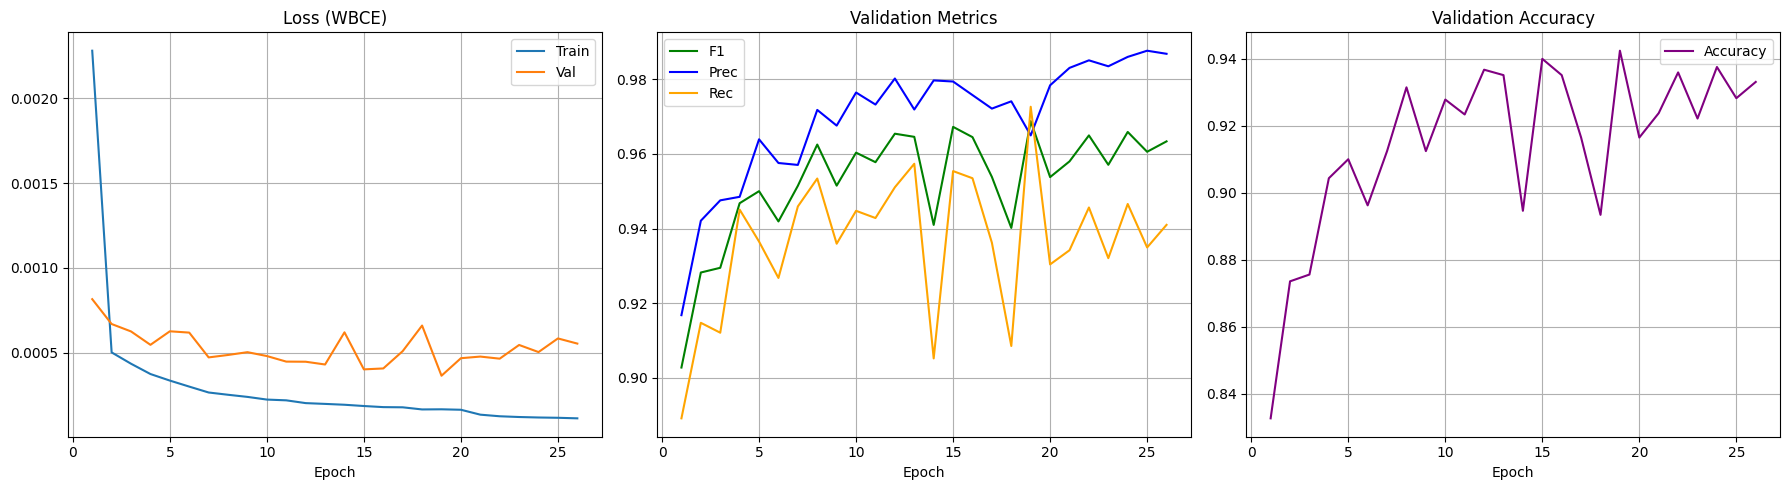

✅ Training curves saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/training_curves.png


In [14]:
  # ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — STEP 8: Plot Training Curves                ║
# ╚══════════════════════════════════════════════════════════╝

import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val')
axes[0].set_title('Loss (WBCE)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

# F1
axes[1].plot(epochs_ran, history['val_f1'],   label='F1',   color='green')
axes[1].plot(epochs_ran, history['val_prec'], label='Prec', color='blue')
axes[1].plot(epochs_ran, history['val_rec'],  label='Rec',  color='orange')
axes[1].set_title('Validation Metrics')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)

# Accuracy
axes[2].plot(epochs_ran, history['val_acc'], label='Accuracy', color='purple')
axes[2].set_title('Validation Accuracy')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plot_path = os.path.join(DATASET_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✅ Training curves saved → {plot_path}")


✅ Best checkpoint loaded (epoch trained to F1=0.9688)


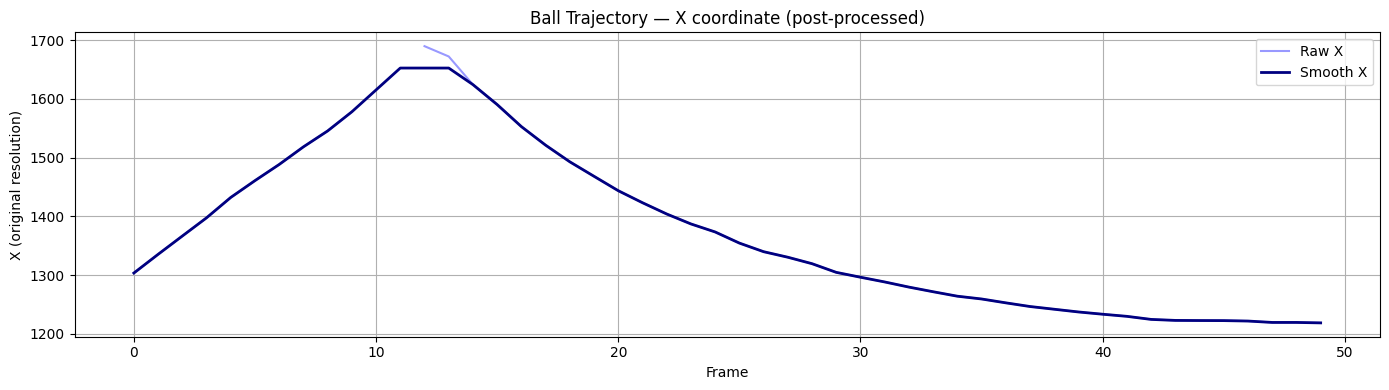

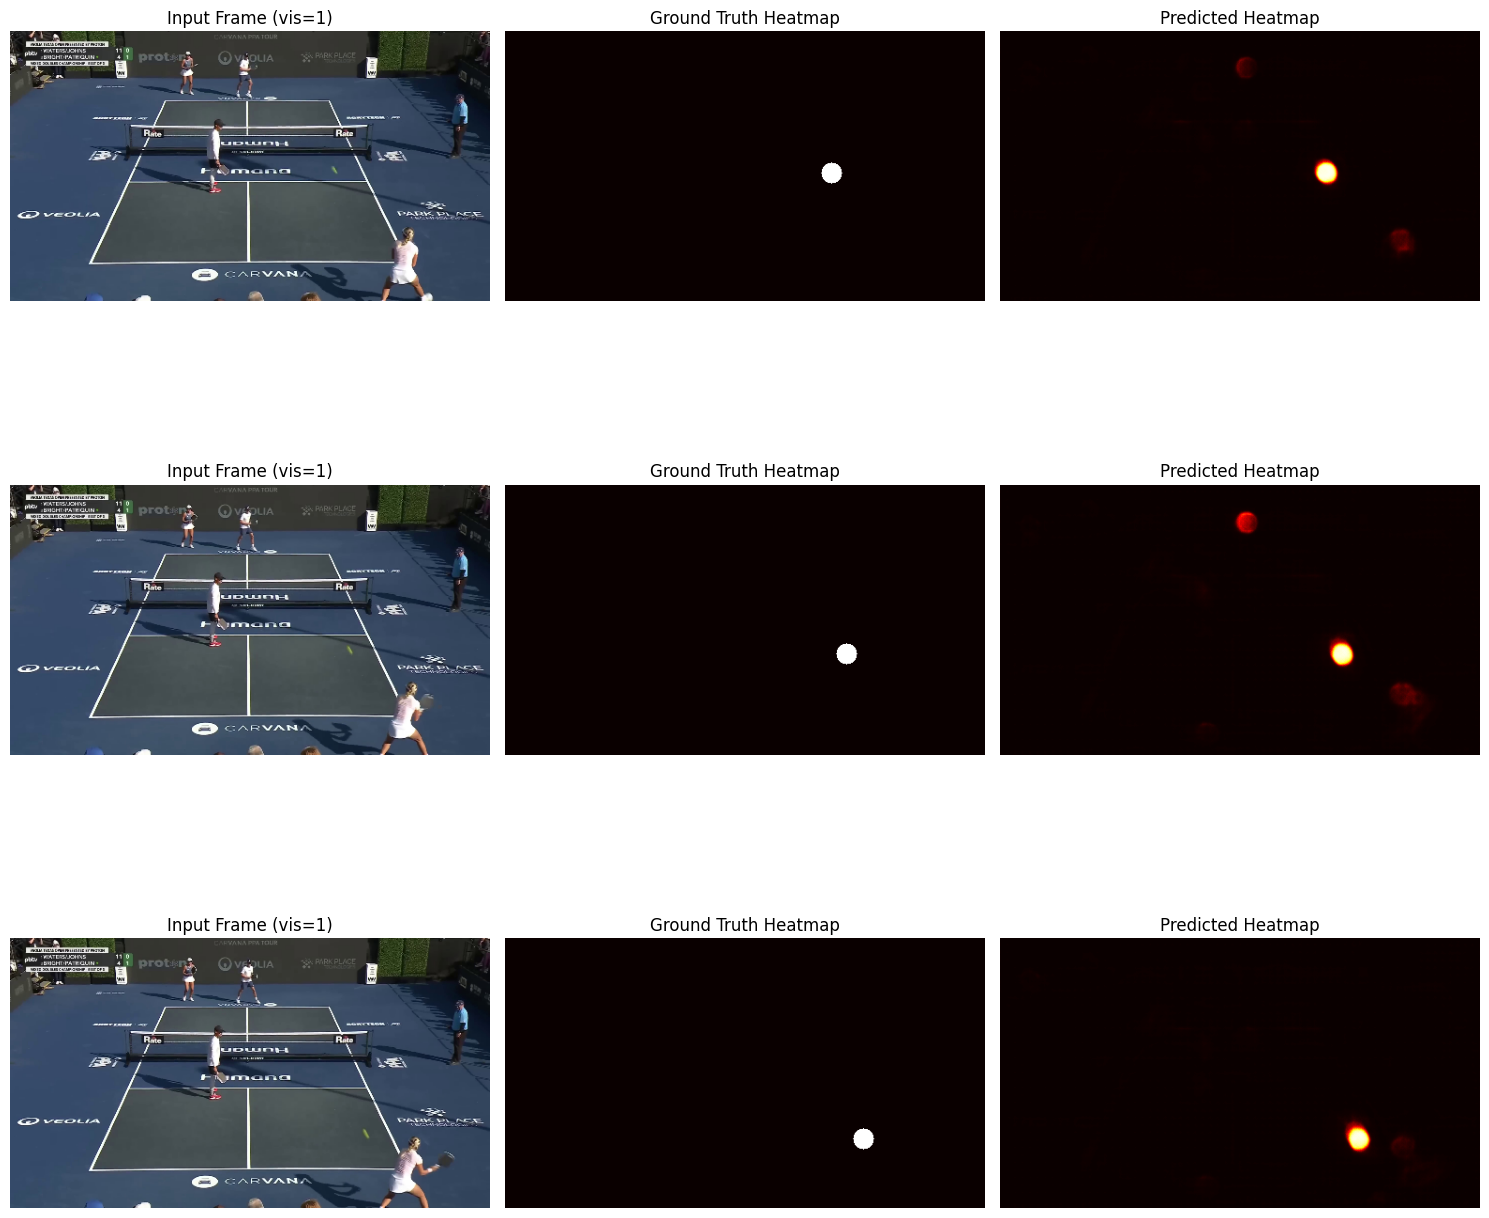

✅ Post-processing complete.
   Trajectory plot   → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/trajectory_postprocess.png
   Sample predictions → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/sample_predictions.png


In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — STEP 9: Post-Processing & Inference Demo    ║
# ╚══════════════════════════════════════════════════════════╝
"""
Post-processing:
  1. Load best checkpoint
  2. Run inference on validation set
  3. Smooth trajectory with median filter over a window
  4. Visualize predictions on sample frames
"""

from scipy.signal import medfilt
import cv2

# ── Load best model ───────────────────────────────────────
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f"✅ Best checkpoint loaded (epoch trained to F1={ckpt['best_f1']:.4f})")

# ── Run inference on first 50 val samples ─────────────────
SMOOTH_WINDOW = 5  # median filter window for trajectory smoothing

raw_xs, raw_ys, smooth_xs, smooth_ys = [], [], [], []

sample_vis  = []   # for visualization frames

with torch.no_grad():
    for i, (frames, hm_gt, vis) in enumerate(val_loader):
        if i >= 25: break  # only first 25 batches

        frames = frames.to(DEVICE)
        pred   = model(frames)
        centers = extract_center(pred.detach(), threshold=0.5)

        for c in centers:
            if c is not None:
                # Scale back to original resolution
                ox = c[0] * 1920 / IMG_W
                oy = c[1] * 1080 / IMG_H
                raw_xs.append(ox)
                raw_ys.append(oy)
            else:
                raw_xs.append(np.nan)
                raw_ys.append(np.nan)

        # Collect a few frame+prediction pairs for visualization
        if i < 3:
            sample_vis.append((
                frames[0].cpu(),
                hm_gt[0].cpu(),
                pred[0].cpu().detach(),
                vis[0].item()
            ))

# ── Smooth trajectory (replace NaNs first) ───────────────
def smooth_trajectory(xs, window=5):
    xs = np.array(xs, dtype=np.float64)
    # Interpolate NaNs
    nans = np.isnan(xs)
    if nans.all():
        return xs
    xs[nans] = np.interp(np.flatnonzero(nans),
                          np.flatnonzero(~nans), xs[~nans])
    return medfilt(xs, kernel_size=window)

smooth_xs = smooth_trajectory(raw_xs, SMOOTH_WINDOW)
smooth_ys = smooth_trajectory(raw_ys, SMOOTH_WINDOW)

# ── Plot trajectory ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
t = range(len(raw_xs))
ax.plot(t, raw_xs,    alpha=0.4, label='Raw X',    color='blue')
ax.plot(t, smooth_xs, linewidth=2, label='Smooth X', color='navy')
ax.set_title('Ball Trajectory — X coordinate (post-processed)')
ax.set_xlabel('Frame'); ax.set_ylabel('X (original resolution)')
ax.legend(); ax.grid(True)
plt.tight_layout()
traj_path = os.path.join(DATASET_DIR, 'trajectory_postprocess.png')
plt.savefig(traj_path, dpi=150)
plt.show()

# ── Visualize sample predictions ─────────────────────────
def unnorm(t):
    img = t.numpy().transpose(1, 2, 0)
    return np.clip(img * 255, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(len(sample_vis), 3, figsize=(15, 5 * len(sample_vis)))
if len(sample_vis) == 1:
    axes = axes[np.newaxis, :]

for row_i, (frames_t, hm_gt, pred_hm, vis_label) in enumerate(sample_vis):
    # Middle frame (I_t = channels 3:6)
    frame_img = unnorm(frames_t[3:6])
    gt_np     = hm_gt.squeeze().numpy()
    pred_np   = pred_hm.squeeze().numpy()

    axes[row_i, 0].imshow(frame_img)
    axes[row_i, 0].set_title(f'Input Frame (vis={int(vis_label)})')
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(gt_np, cmap='hot', vmin=0, vmax=1)
    axes[row_i, 1].set_title('Ground Truth Heatmap')
    axes[row_i, 1].axis('off')

    axes[row_i, 2].imshow(pred_np, cmap='hot', vmin=0, vmax=1)
    axes[row_i, 2].set_title('Predicted Heatmap')
    axes[row_i, 2].axis('off')

plt.tight_layout()
vis_path = os.path.join(DATASET_DIR, 'sample_predictions.png')
plt.savefig(vis_path, dpi=150)
plt.show()
print(f"✅ Post-processing complete.")
print(f"   Trajectory plot   → {traj_path}")
print(f"   Sample predictions → {vis_path}")

In [16]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — STEP 10: Final Evaluation Report             ║
# ╚══════════════════════════════════════════════════════════╝

print("=" * 60)
print("STEP 10 — Final Evaluation on Full Validation Set")
print("=" * 60)

val_loss, acc, prec, rec, f1, tp, fp1, fp2, fn, tn = \
    evaluate(model, val_loader, criterion)

total = tp + fp1 + fp2 + fn + tn

print(f"\n  Val Loss  : {val_loss:.4f}")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"\n  Detailed counts (total={total}):")
print(f"    TP  : {tp}   (correct detections)")
print(f"    FP1 : {fp1}  (false alarms — no ball in GT)")
print(f"    FP2 : {fp2}  (wrong position — outside {EVAL_TOLERANCE}px)")
print(f"    FN  : {fn}   (missed detections)")
print(f"    TN  : {tn}   (correct rejections)")

# Save final report
report_path = os.path.join(DATASET_DIR, 'final_report.txt')
with open(report_path, 'w') as f:
    f.write("TrackNetV5 — Pickleball Tracking — Final Report\n")
    f.write("=" * 50 + "\n")
    f.write(f"Val Loss  : {val_loss:.4f}\n")
    f.write(f"Accuracy  : {acc:.4f}\n")
    f.write(f"Precision : {prec:.4f}\n")
    f.write(f"Recall    : {rec:.4f}\n")
    f.write(f"F1-Score  : {f1:.4f}\n")
    f.write(f"TP:{tp}  FP1:{fp1}  FP2:{fp2}  FN:{fn}  TN:{tn}\n")
    f.write(f"Total     : {total}\n")
    f.write(f"\nModel params: {n_params/1e6:.2f} M\n")
    f.write(f"Best checkpoint: {best_ckpt}\n")

print(f"\n✅ Report saved → {report_path}")
print("🏁 All done!")

STEP 10 — Final Evaluation on Full Validation Set

  Val Loss  : 0.0004
  Accuracy  : 0.9424
  Precision : 0.9649
  Recall    : 0.9726
  F1-Score  : 0.9688

  Detailed counts (total=2467):
    TP  : 2202   (correct detections)
    FP1 : 16  (false alarms — no ball in GT)
    FP2 : 64  (wrong position — outside 4px)
    FN  : 62   (missed detections)
    TN  : 123   (correct rejections)

✅ Report saved → /content/drive/MyDrive/In_Out_Pickleball/tracknetv5_dataset/final_report.txt
🏁 All done!
